In [163]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [214]:
class SMABacktester():
    def __init__(self, symbol, SMA, start, end):
        self.symbol = symbol
        self.SMA = SMA
        self.start = start
        self.end = end
        self.results = None
        self.get_data()
        
    def get_data(self):
        df = yf.download(self.symbol, start=self.start, end=self.end)[['Close']]
        data = df
        data["Close"] = data.Close
        data["returns"] = np.log(data.Close.div(data.Close.shift(1)))
        data["SMA"] = data.Close.rolling(self.SMA).mean()
        data.dropna(inplace=True)
        self.data2 = data
        return data
    
    def test_results(self):
        data = self.data2.copy().dropna()
        data["position"] = np.where(data["Close"].values.ravel() > data["SMA"].values.ravel(),1,-1)
        data["strategy"] = data["returns"] * data.position.shift(1)
        data.dropna(inplace=True)
        data["returnsbh"] = data["returns"].cumsum().apply(np.exp)
        data["returnsstrategy"] = data["strategy"].cumsum().apply(np.exp)
        perf = data["returnsstrategy"].iloc[-1]
        outperf = perf - data["returnsbh"].iloc[-1]
        self.results = data
        ret = np.exp(data["strategy"].sum())
        std = data["strategy"].std() * np.sqrt(252)
        return round(perf, 6), round(outperf, 6)
    
    def plot_results(self):
        if self.results is None:
            print("Run the test please")
        else:
            title = "{} | SMA_S={} ".format(self.symbol, self.SMA)
            plt.style.use("seaborn-v0_8")
            self.results[["returnsbh", "returnsstrategy"]].plot(title=title, figsize=(12, 8))
            plt.show()
    
    def plot_moving_averages(self):
        data = self.data2.copy()
        plt.style.use("seaborn-v0_8")
        data[["Close", "SMA"]].plot(figsize=(12, 8), fontsize=15)
        plt.legend(loc="upper left", fontsize=15)
        plt.title(f"{self.symbol} Price with SMA{self.SMA}", fontsize=15)
        plt.show()
    
    def plot_return_histogram(self):
        data = self.data2.copy()
        ret = data["Close"].pct_change().mul(100).dropna()
        plt.style.use("seaborn-v0_8")
        ret.plot(kind="hist", figsize=(12, 8), bins=100)
        plt.title(f"{self.symbol} Daily Return Distribution", fontsize=15)
        plt.xlabel("Daily Return (%)", fontsize=15)
        plt.ylabel("Frequency", fontsize=15)
        plt.show()

In [218]:
tester=SMABacktester("TSLA",20,"2023-06-20","2025-06-20")

/var/folders/4z/0p4c7jt52_d1bq34q6bc_x800000gn/T/ipykernel_31671/2746481047.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(self.symbol, start=self.start, end=self.end)[['Close']]
[*********************100%***********************]  1 of 1 completed


In [219]:
tester.test_results()

(1.554291, 0.456418)

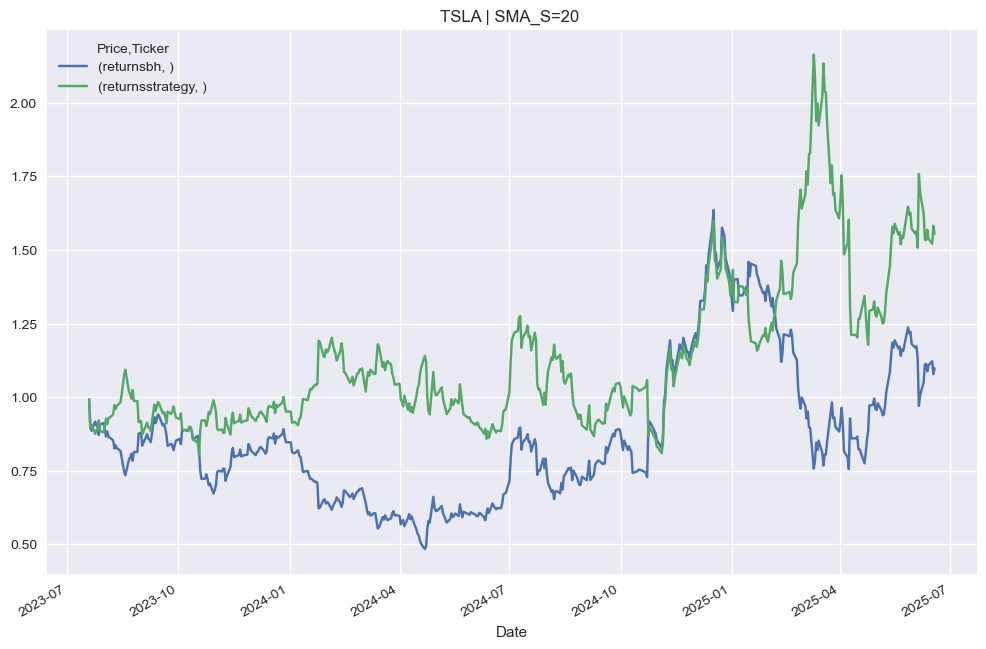

In [220]:
tester.plot_results()

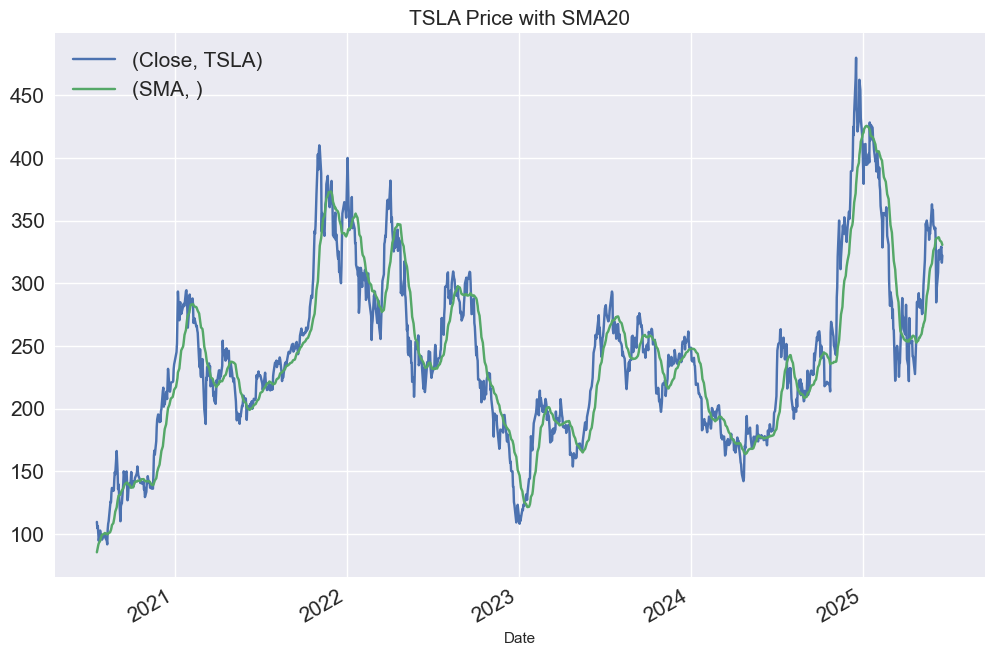

In [209]:
tester.plot_moving_averages()

In [160]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

class SMABacktester:
    def __init__(self, symbol, SMA, start, end, trailing_stop_pct=0.05):
        """
        初始化 SMA 回測器，新增 trailing_stop_pct 參數。
        :param symbol: 股票代碼
        :param SMA: 簡單移動平均線窗口
        :param start: 回測開始日期
        :param end: 回測結束日期
        :param trailing_stop_pct: 移動止盈百分比（例如 0.05 表示 5%）
        """
        self.symbol = symbol
        self.SMA = SMA
        self.start = start
        self.end = end
        self.trailing_stop_pct = trailing_stop_pct
        self.results = None
        self.get_data()
        
    def get_data(self):
        """
        獲取並處理股票數據，計算回報率和 SMA。
        """
        df = yf.download(self.symbol, start=self.start, end=self.end)[['Close']]
        data = df
        data["Close"] = data.Close
        data["returns"] = np.log(data.Close.div(data.Close.shift(1)))
        data["SMA"] = data.Close.rolling(self.SMA).mean()
        data.dropna(inplace=True)
        self.data2 = data
        return data
    
    def test_results(self):
        """
        執行回測，加入移動止盈邏輯。
        :return: (策略表現, 相對於買入持有策略的超額表現)
        """
        data = self.data2.copy()
        data = data.dropna(subset=["Close", "SMA"])
        data["position"] = np.where(data["Close"] > data["SMA"], 1, -1)
        
        # 初始化變量
        position = 0  # 當前持倉：1（多頭）、-1（空頭）、0（無持倉）
        entry_price = 0  # 進場價格
        highest_price = 0  # 多頭持倉期間的最高價
        lowest_price = float('inf')  # 空頭持倉期間的最低價
        data["strategy"] = 0.0
        data["position"] = 0
        
        for i in range(1, len(data)):
            current_price = data["Close"].iloc[i]
            prev_position = position
            
            # 根據 SMA 信號更新持倉
            if data["Close"].iloc[i] > data["SMA"].iloc[i]:
                if position != 1:  # 如果當前不是多頭，則開多單
                    position = 1
                    entry_price = current_price
                    highest_price = current_price
                    lowest_price = float('inf')
            elif data["Close"].iloc[i] < data["SMA"].iloc[i]:
                if position != -1:  # 如果當前不是空頭，則開空單
                    position = -1
                    entry_price = current_price
                    lowest_price = current_price
                    highest_price = 0
            else:
                position = 0  # 無信號時清空持倉
            
            # 更新最高價和最低價
            if position == 1:  # 多頭持倉
                highest_price = max(highest_price, current_price)
                # 檢查移動止盈（價格低於最高價的 x%）
                if current_price <= highest_price * (1 - self.trailing_stop_pct):
                    position = 0  # 平倉
            elif position == -1:  # 空頭持倉
                lowest_price = min(lowest_price, current_price)
                # 檢查移動止盈（價格高於最低價的 x%）
                if current_price >= lowest_price * (1 + self.trailing_stop_pct):
                    position = 0  # 平倉
            
            # 記錄當前持倉
            data["position"].iloc[i] = position
            
            # 計算策略回報
            if prev_position != 0:  # 如果前一時刻有持倉
                data["strategy"].iloc[i] = data["returns"].iloc[i] * prev_position
        
        # 計算累積回報
        data.dropna(inplace=True)
        data["returnsbh"] = data["returns"].cumsum().apply(np.exp)
        data["returnsstrategy"] = data["strategy"].cumsum().apply(np.exp)
        
        # 計算策略表現
        perf = data["returnsstrategy"].iloc[-1]
        outperf = perf - data["returnsbh"].iloc[-1]
        self.results = data
        
        return round(perf, 6), round(outperf, 6)
    
    def plot_results(self):
        """
        繪製買入持有和策略的累積回報曲線。
        """
        if self.results is None:
            print("Run the test please")
        else:
            title = f"{self.symbol} | SMA_S={self.SMA} | Trailing Stop={self.trailing_stop_pct*100}%"
            plt.style.use("seaborn-v0_8")
            self.results[["returnsbh", "returnsstrategy"]].plot(title=title, figsize=(12, 8))
            plt.show()
    
    def plot_moving_averages(self):
        """
        繪製收盤價和 SMA。
        """
        data = self.data2.copy()
        plt.style.use("seaborn-v0_8")
        data[["Close", "SMA"]].plot(figsize=(12, 8), fontsize=15)
        plt.legend(loc="upper left", fontsize=15)
        plt.title(f"{self.symbol} Price with SMA{self.SMA}", fontsize=15)
        plt.show()
    
    def plot_return_histogram(self):
        """
        繪製每日回報分佈直方圖。
        """
        data = self.data2.copy()
        ret = data["Close"].pct_change().mul(100).dropna()
        plt.style.use("seaborn-v0_8")
        ret.plot(kind="hist", figsize=(12, 8), bins=100)
        plt.title(f"{self.symbol} Daily Return Distribution", fontsize=15)
        plt.xlabel("Daily Return (%)", fontsize=15)
        plt.ylabel("Frequency", fontsize=15)
        plt.show()

In [161]:
tester=SMABacktester("AAPL",50,"2020-06-20","2025-06-20")

/var/folders/4z/0p4c7jt52_d1bq34q6bc_x800000gn/T/ipykernel_31671/1230903678.py:27: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(self.symbol, start=self.start, end=self.end)[['Close']]
[*********************100%***********************]  1 of 1 completed


In [162]:
tester.test_results()

KeyError: ['Close', 'SMA']

In [ ]:
def test_results(self):
    """
    執行回測，加入移動止盈邏輯。
    :return: (策略表現, 相對於買入持有策略的超額表現)
    """
    data = self.data2.copy().dropna()
    # 初始化 position 欄位，避免直接修改原始數據
    data["position"] = 0
    data["strategy"] = 0.0
    
    # 初始化變量
    position = 0  # 當前持倉：1（多頭）、-1（空頭）、0（無持倉）
    entry_price = 0  # 進場價格
    highest_price = 0  # 多頭持倉期間的最高價
    lowest_price = float('inf')  # 空頭持倉期間的最低價
    
    for i in range(1, len(data)):
        current_price = data["Close"].iloc[i]
        sma_value = data["SMA"].iloc[i]
        prev_position = position
        
        # 根據 SMA 信號更新持倉
        if current_price > sma_value:
            if position != 1:  # 如果當前不是多頭，則開多單
                position = 1
                entry_price = current_price
                highest_price = current_price
                lowest_price = float('inf')
        elif current_price < sma_value:
            if position != -1:  # 如果當前不是空頭，則開空單
                position = -1
                entry_price = current_price
                lowest_price = current_price
                highest_price = 0
        else:
            position = 0  # 無信號時清空持倉
        
        # 更新最高價和最低價
        if position == 1:  # 多頭持倉
            highest_price = max(highest_price, current_price)
            # 檢查移動止盈（價格低於最高價的 x%）
            if current_price <= highest_price * (1 - self.trailing_stop_pct):
                position = 0  # 平倉
        elif position == -1:  # 空頭持倉
            lowest_price = min(lowest_price, current_price)
            # 檢查移動止盈（價格高於最低價的 x%）
            if current_price >= lowest_price * (1 + self.trailing_stop_pct):
                position = 0  # 平倉
        
        # 記錄當前持倉
        data["position"].iloc[i] = position
        
        # 計算策略回報
        if prev_position != 0:  # 如果前一時刻有持倉
            data["strategy"].iloc[i] = data["returns"].iloc[i] * prev_position
    
    # 計算累積回報
    data.dropna(inplace=True)
    data["returnsbh"] = data["returns"].cumsum().apply(np.exp)
    data["returnsstrategy"] = data["strategy"].cumsum().apply(np.exp)
    
    # 計算策略表現
    perf = data["returnsstrategy"].iloc[-1]
    outperf = perf - data["returnsbh"].iloc[-1]
    self.results = data
    
    return round(perf, 6), round(outperf, 6)